In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data

In [3]:
df = pd.read_csv('dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [15]:
X = pd.read_csv('dataset_part_3.csv')
X.head(10)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
5,6.0,3325.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6,7.0,2296.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
7,8.0,1316.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
8,9.0,4535.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
9,10.0,4428.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [7]:
Y = df['Class'].to_numpy()
Y

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

### Standardize the data

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

### Split the data into training and testing (80/20)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

y_test.shape

(18,)

In [23]:
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
len(numerical_features) == X.shape[1]

True

### Logistic Regression with GridSearch

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

parameters = {'model__C':[0.01, 0.1, 1],
              'model__penalty': ['l2'],
              'model__solver': ['lbfgs']}

lr = LogisticRegression()
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', lr)
])

logreg_cv = GridSearchCV(pipeline, parameters, cv=10, scoring='accuracy', verbose=2)
logreg_cv.fit(X_train, y_train)

Fitting 10 folds for each of 3 candidates, totalling 30 fits
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.1, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.1, mode

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             param_grid={'model__C': [0.01, 0.1, 1], 'model__penalty': ['l2'],
                         'model__solver': ['lbfgs']},
             scoring='accuracy', verbose=2)

In [31]:
print(f"Best Logistic Regression Parameters: {logreg_cv.best_params_}")
print(f"Best Logistic Regression Accuracy Score: {logreg_cv.best_score_:.4f}")

Best Logistic Regression Parameters: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best Logistic Regression Accuracy Score: 0.8179


In [33]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = logreg_cv.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.93      0.93      0.93        14

    accuracy                           0.89        18
   macro avg       0.84      0.84      0.84        18
weighted avg       0.89      0.89      0.89        18



In [34]:
def plot_confusion_matrix(y, y_predict):
    cm = confusion_matrix(y, y_predict)

    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax)
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('Actual Labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['Did not Land', 'Land'])
    ax.yaxis.set_ticklabels(['Did not Land', 'Land'])
    plt.show()

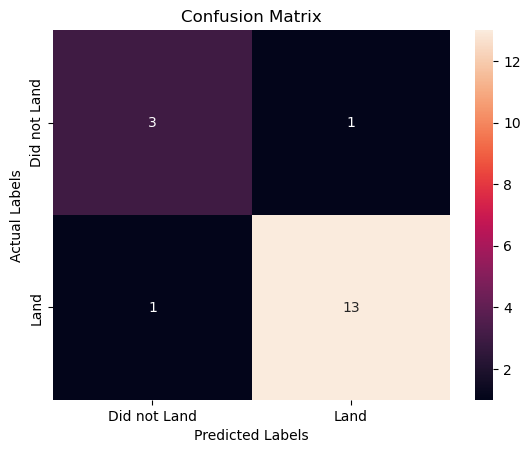

In [35]:
plot_confusion_matrix(y_test, y_pred)

### Support Vector Machines with GridSearch

In [36]:
from sklearn.svm import SVC

parameters = {'kernel':('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)
              }

svm = SVC()

In [40]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_cv = GridSearchCV(svm, parameters, verbose=2, cv=10, scoring='accuracy')
svm_cv.fit(X_train_scaled, y_train)

y_hat_svc = svm_cv.predict(X_test_scaled)

print(f"Best SVM Hyperparameters: {svm_cv.best_params_}")
print(f"Best SVM Accuracy score: {svm_cv.best_score_:.4f}")

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ................C=0.001, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ...................C=0.001, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.001, gamma=0

In [41]:
print(classification_report(y_test, y_hat_svc))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.93      0.93      0.93        14

    accuracy                           0.89        18
   macro avg       0.84      0.84      0.84        18
weighted avg       0.89      0.89      0.89        18



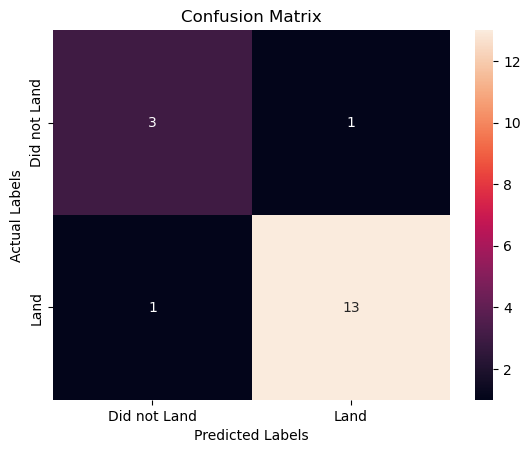

In [42]:
plot_confusion_matrix(y_test, y_hat_svc)

### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2*n for n in range(1, 10)],
              'max_features': ['sqrt', 'log2'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, verbose=2, scoring='accuracy', cv=10)
tree_cv.fit(X_train_scaled, y_train)

y_hat_tree = tree_cv.predict(X_test_scaled)

print(f"Decision Tree Best Parameters: {tree_cv.best_params_}")
print(f"Decision Tree Best Accuracy Score: {tree_cv.best_score_:.2f}")